# Support Vector Regression (SVR)

## Main Math for Support Vector Regression

Support Vector Regression (SVR) balances model complexity with prediction errors outside a tolerance of $\varepsilon$.

- $x$: input variable.
- $y$: actual output.
- $\hat{y}$: predicted output.
- $n$: number of training observations.
- $\varepsilon \geq 0$: error tolerance.
- $C>0$: strength of the penalty for errors beyond that tolerance.

### 1. The regression equation

For one input, linear SVR uses the same equation as simple linear regression:

$$
\hat{y} = b_0 + b_1x
$$

For nonlinear relationships, SVR uses a feature transformation $\phi(x)$:

$$
\hat{y} = b_0 + \mathbf{w}^{\mathsf{T}}\phi(x)
$$

Here, $b_0$ is the intercept and $\mathbf{w}$ contains the feature weights. When $\phi(x)=x$, the single weight corresponds to $b_1$.

### 2. Residuals: prediction errors

For training observation $i$:

$$
e_i = y_i-\hat{y}_i
$$

A positive residual means underestimation; a negative residual means overestimation.

SVR uses the **ε-insensitive loss**:

$$
L_{\varepsilon}(e_i)
=
\max(0,\lvert e_i\rvert-\varepsilon)
$$

Predictions within the tolerance band incur zero loss:

$$
\hat{y}_i-\varepsilon
\leq y_i
\leq \hat{y}_i+\varepsilon
$$

Outside this band, only the excess error is penalized. For example, if $\varepsilon=2$ and $\lvert e_i\rvert=5$, the loss is $3$.

### 3. Finding the best-fitting model

SVR fits the weights and intercept by solving:

$$
\min_{\mathbf{w},b_0}
\left[
\frac{1}{2}\lVert\mathbf{w}\rVert^2
+
C\sum_{i=1}^{n}
\max\left(0,\left|y_i-\hat{y}_i\right|-\varepsilon\right)
\right]
$$

The first term discourages large weights; the second penalizes errors outside the tolerance band. This replaces the squared-error objective used in the earlier models. [Mathematical formulation](https://scikit-learn.org/stable/modules/svm.html#svr)

- **Larger $C$:** greater emphasis on reducing errors outside the band.
- **Smaller $C$:** stronger regularization relative to the error penalty.
- **Larger $\varepsilon$:** a wider band of unpenalized errors.

$C$ and $\varepsilon$ are hyperparameters selected before fitting, typically using validation data or cross-validation. [SVR parameter documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html)

### 4. Calculating the coefficients and intercept

A numerical optimizer determines the fitted parameters. Kernel SVR expresses predictions as:

$$
\hat{y}(x)
=
b_0+
\sum_{i=1}^{n}
(\alpha_i-\alpha_i^*)K(x_i,x)
$$

The fitted coefficients satisfy:

$$
0\leq\alpha_i,\alpha_i^*\leq C,
\qquad
\sum_{i=1}^{n}(\alpha_i-\alpha_i^*)=0
$$

Observations with nonzero $\alpha_i-\alpha_i^*$ are **support vectors**; only these contribute to the prediction sum. [SVR solution](https://scikit-learn.org/stable/modules/svm.html#svr)

The kernel calculates feature-space inner products:

$$
K(x_i,x)=\phi(x_i)^{\mathsf{T}}\phi(x)
$$

A common choice is the **Radial Basis Function (RBF) kernel**:

$$
K(x_i,x)=\exp\left(-\gamma\lVert x_i-x\rVert^2\right)
$$

For one input, $\lVert x_i-x\rVert^2=(x_i-x)^2$. Larger $\gamma$ makes similarity decrease more quickly with distance, giving each support vector a more localized influence. [Kernel definitions](https://scikit-learn.org/stable/modules/svm.html#kernel-functions)

Linear SVR therefore shares the equation of simple linear regression, while its fitting objective differs. Kernel SVR extends that approach to curved relationships.

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
datatset = pd.read_csv('Position_Salaries.csv')
X = datatset.iloc[:, 1:-1].values
y = datatset.iloc[:, -1].values

In [3]:
print(X)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]


In [4]:
print(y)

[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


In [5]:
y = y.reshape(len(y), 1)

In [6]:
print(y)

[[  45000]
 [  50000]
 [  60000]
 [  80000]
 [ 110000]
 [ 150000]
 [ 200000]
 [ 300000]
 [ 500000]
 [1000000]]


## Feature Scaling

In [7]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y)

In [8]:
print(X)

[[-1.5666989 ]
 [-1.21854359]
 [-0.87038828]
 [-0.52223297]
 [-0.17407766]
 [ 0.17407766]
 [ 0.52223297]
 [ 0.87038828]
 [ 1.21854359]
 [ 1.5666989 ]]


In [9]:
print(y)

[[-0.72004253]
 [-0.70243757]
 [-0.66722767]
 [-0.59680786]
 [-0.49117815]
 [-0.35033854]
 [-0.17428902]
 [ 0.17781001]
 [ 0.88200808]
 [ 2.64250325]]


## Training the SVR model on the whole dataset

In [10]:
from sklearn.svm import SVR
regressor = SVR(kernel = 'rbf')
regressor.fit(X, y)

d:\ML\Machine-Learning-A-Z\.venv\Lib\site-packages\sklearn\utils\validation.py:1368: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


## Predicting a new result

In [14]:
sc_y.inverse_transform(regressor.predict(sc_X.transform([[6.5]])).reshape(1, -1))

array([[170370.0204065]])

## Visualising the SVR results

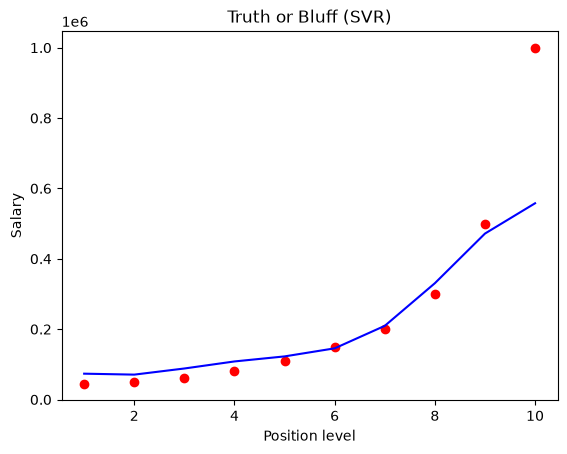

In [15]:
plt.scatter(sc_X.inverse_transform(X), sc_y.inverse_transform(y), color='red')
plt.plot(sc_X.inverse_transform(X), sc_y.inverse_transform(regressor.predict(X).reshape(-1, 1)), color='blue')
plt.title('Truth or Bluff (SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

## Visualising the SVR results (for higher resolution and smoother curve)

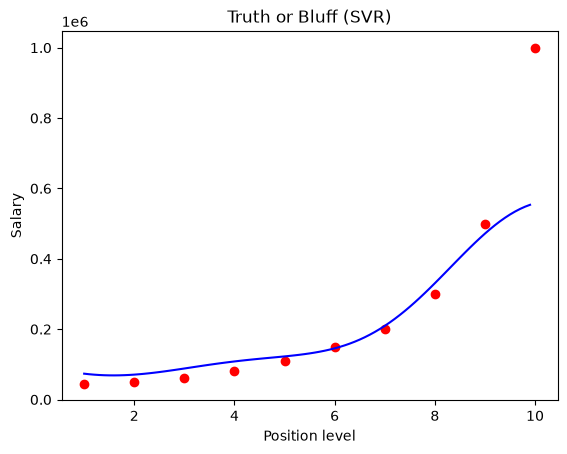

In [16]:
X_grid = np.arange(sc_X.inverse_transform(X).min(), sc_X.inverse_transform(X).max(), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(sc_X.inverse_transform(X), sc_y.inverse_transform(y), color = 'red')
plt.plot(X_grid, sc_y.inverse_transform(regressor.predict(sc_X.transform(X_grid)).reshape(-1, 1)), color = 'blue')
plt.title('Truth or Bluff (SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()